# HD209458b base-BC convergence test models

Each sub-folder is one EXHALE run of HD209458b. The folder name encodes the
distinguishing axes as `<base>_<solver>_He{0,1}_met{0,CNO}[_flags]`:

| token | meaning |
|---|---|
| `dens` / `pres1ub` | base BC: density (n0=1e14) / pressure-anchored (1 microbar, n0 derived ~5e12) |
| `PLM` / `PWN` | single-stage PLM (stall stop) / two-stage PLM->WENO3 + Newton finish |
| `He0` / `He1` | He 2$^3$S (metastable) off / on |
| `met0` / `metCNO` | trace metals off / on (C, N, O) |
| `cold` / `windae` | cold hydrostatic IC / Wind-AE warm-start IC |
| flags | `Shap` (Shapiro filter on), `Vflux` (mass-flux base velocity), `Force` (force_start), `spherical` |

The reference is `dens_PLM_He0_metCNO_cold`. This notebook plots it in detail,
overlays the pressure-base run, and compares every model.

In [1]:
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../examples'))
import exhale_io as aio

HERE = os.path.abspath('.')
# folder naming: <base>_<solver>_He{0,1}_met{0,CNO}[_flags]
#   base   : dens (n0=1e14) | pres1ub (pressure 1 microbar)
#   solver : PLM (single-stage, stall stop) | PWN (PLM->WENO3->Newton)
#   flags  : Shap, Vflux, windae, Force (only when present)
REFERENCE = 'dens_PLM_He0_metCNO_cold'   # density-base single-PLM baseline


def load_model(folder):
    """Load one model sub-folder, preferring _adv files but falling back to
    the eq files for runs that have not written _adv yet (still running /
    crashed). Returns an exhale_io.Run or None if no output is present."""
    out = os.path.join(folder, 'output')
    inp = os.path.join(folder, 'input.inp')
    inp = inp if os.path.exists(inp) else ''
    has_adv = os.path.exists(os.path.join(out, 'Hydro_ioniz_adv.txt'))
    if not (has_adv or os.path.exists(os.path.join(out, 'Hydro_ioniz.txt'))):
        return None
    return aio.load_run(out, inp, adv=has_adv)


def rneg_pct(m):
    """Radius-weighted infall fraction (%): the fraction of the LINEAR radius
    range [r_1, r_N] over which v<0. The raw cell-count neg% is biased by the
    non-uniform grid (cells are packed near the base), so the dense near-base
    sliver of sub-10 m/s noise inflates it; weighting each cell by its width dr
    measures the actual radial extent of infall and cleanly separates real
    infall (tens of %) from base noise (<3%)."""
    r = m.r
    edges = np.concatenate(([r[0]], 0.5 * (r[:-1] + r[1:]), [r[-1]]))
    dr = np.diff(edges)
    return 100.0 * dr[m.v < 0].sum() / dr.sum()


# discover every model sub-folder that has output, reference first
folders = sorted(d for d in os.listdir(HERE)
                 if os.path.isdir(os.path.join(HERE, d))
                 and os.path.exists(os.path.join(HERE, d, 'output')))
if REFERENCE in folders:
    folders = [REFERENCE] + [f for f in folders if f != REFERENCE]

models = {}
for f in folders:
    run = load_model(os.path.join(HERE, f))
    if run is not None:
        models[f] = run
        print(f'{f:52s}  N={len(run.r):4d}  '
              f'v_base={run.v_kms[0]:+.3f}  v_out={run.v_kms[-1]:+.3f} km/s  '
              f'neg(r)={rneg_pct(run):5.2f}%')
    else:
        print(f'{f:52s}  (no output yet)')

dens_PLM_He0_metCNO_cold                              N= 504  v_base=+0.000  v_out=+6.773 km/s  neg(r)= 3.85%
dens12p5_PWN_He0_met0_cold                            N= 504  v_base=+0.000  v_out=+8.581 km/s  neg(r)= 0.01%
dens_PLM_He0_met0_cold_Shap                           N= 504  v_base=+0.000  v_out=-13.344 km/s  neg(r)=99.99%
dens_PLM_He0_met0_cold_Shap_Vflux                     N= 504  v_base=+0.000  v_out=-13.322 km/s  neg(r)=99.99%
dens_PLM_He0_met0_cold_Vflux                          N= 504  v_base=+0.000  v_out=+8.577 km/s  neg(r)= 0.03%
dens_PLM_He0_met0_windae_spherical                    N= 504  v_base=+0.000  v_out=+3.678 km/s  neg(r)= 0.63%
dens_PLM_He0_met0_windae_spherical_Shap_Vflux_Force   N= 504  v_base=+0.000  v_out=-20.026 km/s  neg(r)=95.06%
dens_PWN_He0_met0_cold                                N= 504  v_base=+0.000  v_out=+8.805 km/s  neg(r)= 0.02%


dens_PWN_He0_met0_windae_spherical                    N= 504  v_base=+0.000  v_out=+5.766 km/s  neg(r)= 1.40%
dens_PWN_He1_metCNO_cold                              N= 504  v_base=+0.000  v_out=+6.790 km/s  neg(r)= 2.32%
pres1ub_PLMN_He1_metFULL_cold                         N= 504  v_base=+0.000  v_out=+6.103 km/s  neg(r)= 1.84%
pres1ub_PLM_He0_met0_cold                             N= 504  v_base=+0.000  v_out=+8.364 km/s  neg(r)= 0.01%
pres1ub_PWN_He0_met0_cold                             N= 504  v_base=+0.000  v_out=+8.592 km/s  neg(r)= 0.01%
pres1ub_PWN_He1_metCNO_cold                           N= 504  v_base=+0.000  v_out=+6.629 km/s  neg(r)= 1.56%
pres1ub_PWN_He1_metCNO_cold_Shap                      N= 504  v_base=+0.000  v_out=+7.450 km/s  neg(r)=25.29%
pres1ub_PWN_He1_metCNO_cold_Vflux                     N= 504  v_base=+0.000  v_out=+6.626 km/s  neg(r)= 1.61%
pres1ub_PWN_He1_metFULL_cold                          N= 504  v_base=+0.000  v_out=+6.293 km/s  neg(r)= 2.16%
pres1ub_PW

## Production runs (PLM→WENO3→Newton): base BC × physics

Same figure as `fig_production.png` — density vs pressure base (solid vs dashed), no-metals vs full-physics (He 2³S + C/N/O metals).

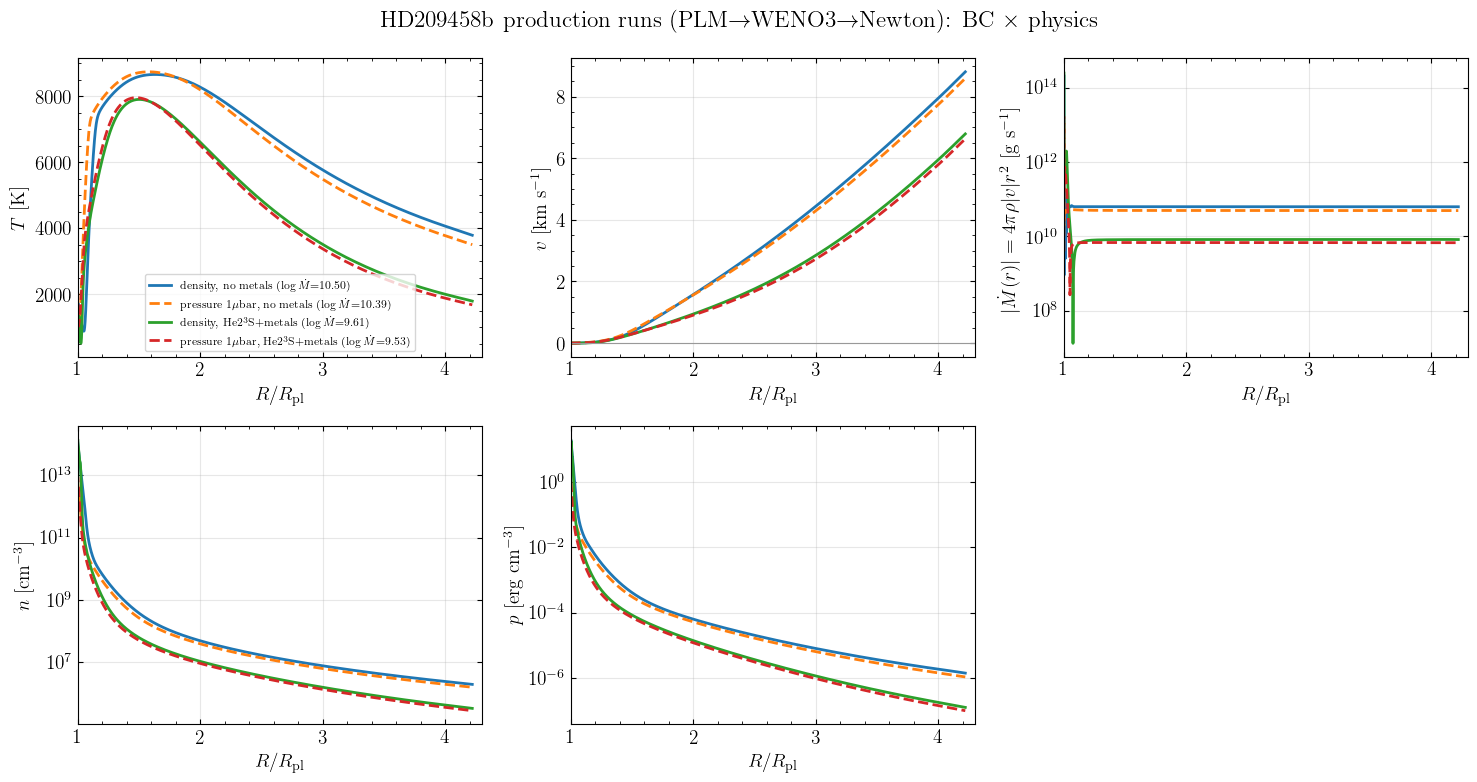

In [2]:
run = models[REFERENCE]   # kept for the ionization/energetics cell below

# Production runs (PLM->WENO3->Newton): base BC x physics.
# Same figure as fig_production.png: density vs pressure (solid vs dashed),
# no-metals vs full-physics (He 2^3S + C/N/O metals).
PROD = [
    ('dens_PWN_He0_met0_cold',      'density, no metals',                   'C0', '-'),
    ('pres1ub_PWN_He0_met0_cold',   r'pressure 1$\mu$bar, no metals',       'C1', '--'),
    ('dens_PWN_He1_metCNO_cold',    r'density, He2$^3$S+metals',            'C2', '-'),
    ('pres1ub_PWN_He1_metCNO_cold', r'pressure 1$\mu$bar, He2$^3$S+metals', 'C3', '--'),
]
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for name, lab, col, ls in PROD:
    m = models.get(name)
    if m is None:
        continue
    try:
        lab = lab + r' ($\log\dot{M}$=' + f'{aio.mdot_log10(m):.2f}' + ')'
    except Exception:
        pass
    kw = dict(color=col, ls=ls, lw=2.0, label=lab)
    # local mass flux = 4 pi rho v r^2 = Mdot(r) [g/s]; flat in r where converged.
    # plotted as |Mdot(r)| on a log axis so the near-base infall noise (high rho,
    # tiny v<0) does not swamp the linear scale and hide the flat wind plateau.
    Rp = m.inp.get('Rp_RJ', 1.0) * aio.RJ
    mflux = 4.0 * np.pi * m.n * aio.mu * m.v * (m.r * Rp) ** 2
    ax[0, 0].plot(m.r, m.T, **kw)
    ax[0, 1].plot(m.r, m.v_kms, **kw)
    ax[0, 2].semilogy(m.r, np.abs(mflux), **kw)
    ax[1, 0].semilogy(m.r, m.n, **kw)
    ax[1, 1].semilogy(m.r, m.p, **kw)
ax[0, 0].set_ylabel(r'$T$ [K]')
ax[0, 1].set_ylabel(r'$v$ [km s$^{-1}$]')
ax[0, 1].axhline(0, color='0.6', lw=0.8)
ax[0, 2].set_ylabel(r'$|\dot{M}(r)|=4\pi\rho |v| r^2$ [g s$^{-1}$]')
ax[1, 0].set_ylabel(r'$n$ [cm$^{-3}$]')
ax[1, 1].set_ylabel(r'$p$ [erg cm$^{-3}$]')
ax[1, 2].axis('off')
for a in (ax[0, 0], ax[0, 1], ax[0, 2], ax[1, 0], ax[1, 1]):
    a.set_xlabel(r'$R/R_{\rm pl}$')
    a.grid(alpha=0.3)
    a.set_xlim(1, 4.3)
ax[0, 0].legend(fontsize=8, loc='best')
fig.suptitle(r'HD209458b production runs (PLM$\to$WENO3$\to$Newton): BC $\times$ physics')
fig.tight_layout()
plt.show()

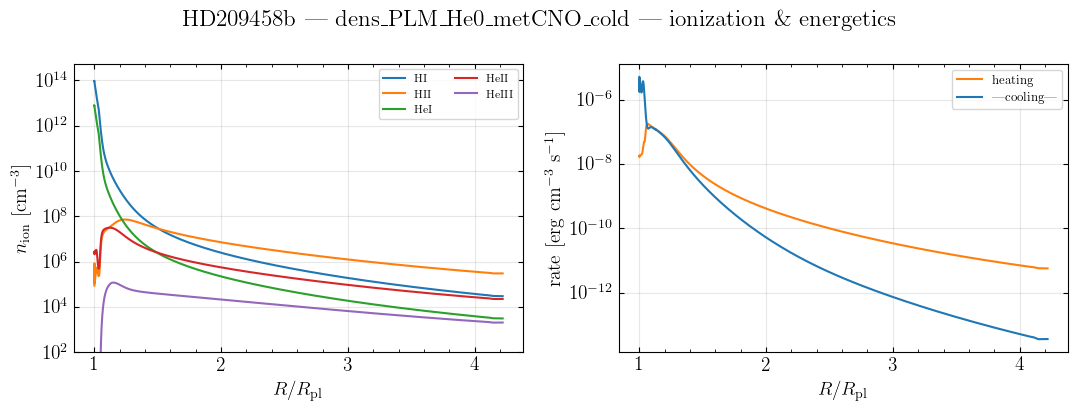

In [3]:
# ionization structure and heating/cooling of the reference run
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name in ['HI', 'HII', 'HeI', 'HeII', 'HeIII']:
    if name in run.ion:
        ax[0].semilogy(run.r, run.ion[name], label=name)
ax[0].set_ylabel(r'$n_{\rm ion}$ [cm$^{-3}$]')
ax[0].set_ylim(bottom=1e2)
ax[0].legend(ncol=2, fontsize=8)
ax[1].semilogy(run.r, run.heat, 'C1', label='heating')
ax[1].semilogy(run.r, np.abs(run.cool), 'C0', label='|cooling|')
ax[1].set_ylabel(r'rate [erg cm$^{-3}$ s$^{-1}$]')
ax[1].legend(fontsize=9)
for a in ax:
    a.set_xlabel(r'$R/R_{\rm pl}$')
    a.grid(alpha=0.3)
fig.suptitle(r'HD209458b --- ' + REFERENCE.replace('_', r'\_') +
             r' --- ionization \& energetics')
fig.tight_layout()
plt.show()

## All models overlaid

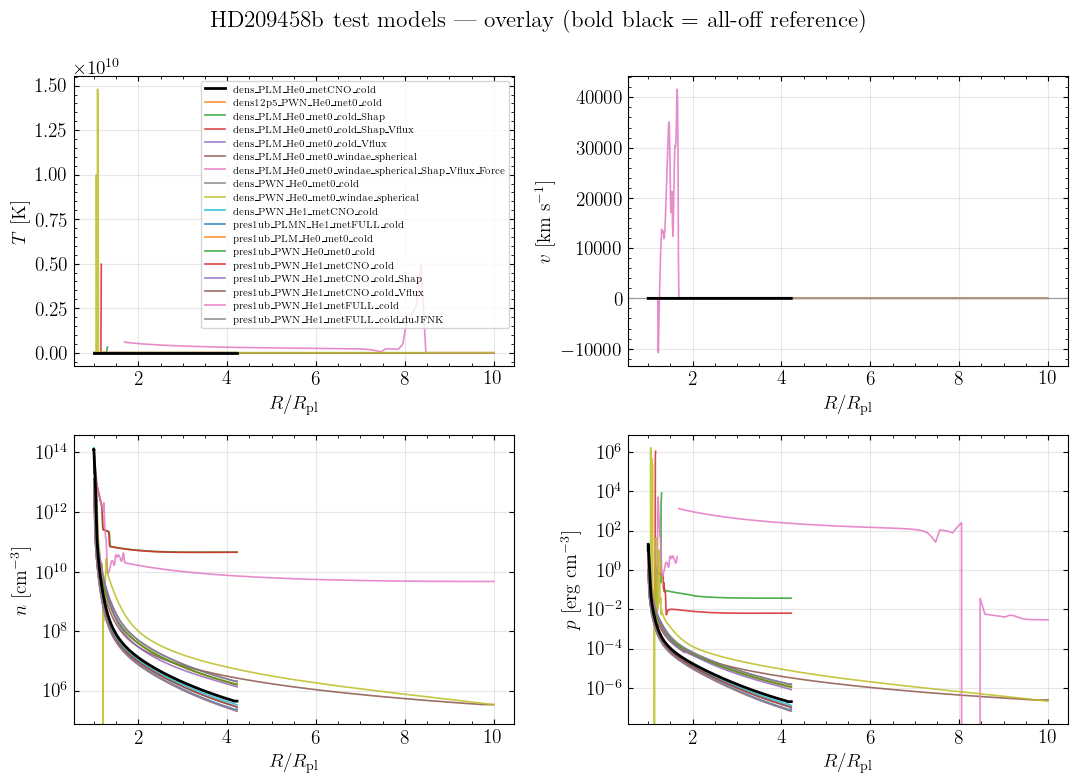

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for i, (name, m) in enumerate(models.items()):
    style = dict(lw=2.0, color='k', zorder=5) if name == REFERENCE \
        else dict(lw=1.2, color=f'C{i}', alpha=0.85)
    lab = name.replace('_', r'\_')
    ax[0, 0].plot(m.r, m.T, label=lab, **style)
    ax[0, 1].plot(m.r, m.v_kms, label=lab, **style)
    ax[1, 0].semilogy(m.r, m.n, label=lab, **style)
    ax[1, 1].semilogy(m.r, m.p, label=lab, **style)
ax[0, 0].set_ylabel(r'$T$ [K]')
ax[0, 1].set_ylabel(r'$v$ [km s$^{-1}$]')
ax[0, 1].axhline(0, color='0.6', lw=0.8)
ax[1, 0].set_ylabel(r'$n$ [cm$^{-3}$]')
ax[1, 1].set_ylabel(r'$p$ [erg cm$^{-3}$]')
for a in ax.flat:
    a.set_xlabel(r'$R/R_{\rm pl}$')
    a.grid(alpha=0.3)
ax[0, 0].legend(fontsize=7, loc='best')
fig.suptitle(r'HD209458b test models --- overlay (bold black = all-off reference)')
fig.tight_layout()
plt.show()

In [5]:
# summary table: base/outer velocity, radius-weighted infall fraction, log10 Mdot
# neg%(r) = fraction of the LINEAR radius range with v<0 (radius-weighted, see
# rneg_pct above) -- NOT the cell-count fraction, which the non-uniform grid
# inflates via the densely-gridded near-base noise.
print(f'{"model":52s} {"v_base":>8s} {"v_out":>8s} {"neg%(r)":>8s} {"logMdot":>8s}')
print('-' * 90)
for name, m in models.items():
    try:
        lm = aio.mdot_log10(m)
    except Exception:
        lm = float('nan')
    print(f'{name:52s} {m.v_kms[0]:+8.3f} {m.v_kms[-1]:+8.3f} '
          f'{rneg_pct(m):7.2f}% {lm:8.3f}')

model                                                  v_base    v_out  neg%(r)  logMdot
------------------------------------------------------------------------------------------
dens_PLM_He0_metCNO_cold                               +0.000   +6.773    3.85%    9.723
dens12p5_PWN_He0_met0_cold                             +0.000   +8.581    0.01%   10.381
dens_PLM_He0_met0_cold_Shap                            +0.000  -13.344   99.99%      nan
dens_PLM_He0_met0_cold_Shap_Vflux                      +0.000  -13.322   99.99%      nan
dens_PLM_He0_met0_cold_Vflux                           +0.000   +8.577    0.03%   10.501
dens_PLM_He0_met0_windae_spherical                     +0.000   +3.678    0.63%   10.080
dens_PLM_He0_met0_windae_spherical_Shap_Vflux_Force    +0.000  -20.026   95.06%      nan
dens_PWN_He0_met0_cold                                 +0.000   +8.805    0.02%   10.495
dens_PWN_He0_met0_windae_spherical                     +0.000   +5.766    1.40%   10.368
dens_PWN_He1_metCNO

## Full-metals JFNK reconstruction path: PWN vs PLMN

Comparison of the two full-metal (He 2³S + C/N/O/Mg/Ca/Na/Fe) runs that differ only in the path to the Newton finish:
`pres1ub_PWN_He1_metFULL_cold` (PLM→WENO3→JFNK) vs `pres1ub_PLMN_He1_metFULL_cold` (PLM→JFNK, skipping WENO3). Both **fail JFNK with `info=2`** and fall back to a stall; the relaxed profiles are nearly identical, so the WENO3 stage is not the JFNK bottleneck — the stiff full-physics residual is.

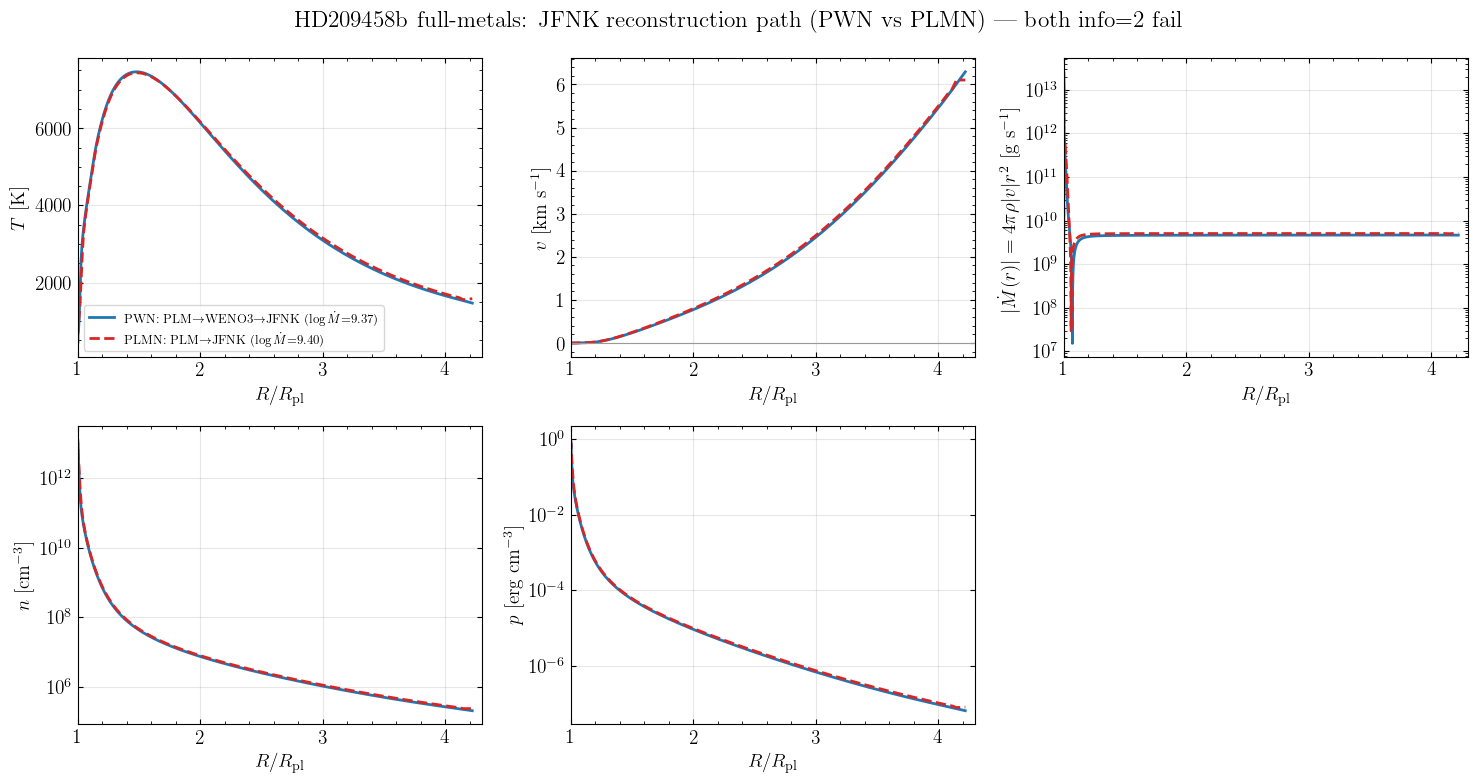

In [6]:
# Full-metals: JFNK reconstruction path -- PWN (PLM->WENO3->JFNK) vs PLMN (PLM->JFNK)
JFNK_CMP = [
    ('pres1ub_PWN_He1_metFULL_cold',  r'PWN: PLM$\to$WENO3$\to$JFNK', 'C0', '-'),
    ('pres1ub_PLMN_He1_metFULL_cold', r'PLMN: PLM$\to$JFNK',          'C3', '--'),
]
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for name, lab, col, ls in JFNK_CMP:
    m = models.get(name)
    if m is None:
        print('missing:', name)
        continue
    try:
        lab = lab + r' ($\log\dot{M}$=' + f'{aio.mdot_log10(m):.2f}' + ')'
    except Exception:
        pass
    kw = dict(color=col, ls=ls, lw=2.0, label=lab)
    # local mass flux = 4 pi rho v r^2 = Mdot(r) [g/s]; flat in r where converged.
    # plotted as |Mdot(r)| on a log axis so the near-base infall noise (high rho,
    # tiny v<0) does not swamp the linear scale and hide the flat wind plateau.
    Rp = m.inp.get('Rp_RJ', 1.0) * aio.RJ
    mflux = 4.0 * np.pi * m.n * aio.mu * m.v * (m.r * Rp) ** 2
    ax[0, 0].plot(m.r, m.T, **kw)
    ax[0, 1].plot(m.r, m.v_kms, **kw)
    ax[0, 2].semilogy(m.r, np.abs(mflux), **kw)
    ax[1, 0].semilogy(m.r, m.n, **kw)
    ax[1, 1].semilogy(m.r, m.p, **kw)
ax[0, 0].set_ylabel(r'$T$ [K]')
ax[0, 1].set_ylabel(r'$v$ [km s$^{-1}$]')
ax[0, 1].axhline(0, color='0.6', lw=0.8)
ax[0, 2].set_ylabel(r'$|\dot{M}(r)|=4\pi\rho |v| r^2$ [g s$^{-1}$]')
ax[1, 0].set_ylabel(r'$n$ [cm$^{-3}$]')
ax[1, 1].set_ylabel(r'$p$ [erg cm$^{-3}$]')
ax[1, 2].axis('off')
for a in (ax[0, 0], ax[0, 1], ax[0, 2], ax[1, 0], ax[1, 1]):
    a.set_xlabel(r'$R/R_{\rm pl}$')
    a.grid(alpha=0.3)
    a.set_xlim(1, 4.3)
ax[0, 0].legend(fontsize=9, loc='best')
fig.suptitle(r'HD209458b full-metals: JFNK reconstruction path (PWN vs PLMN) --- both info=2 fail')
fig.tight_layout()
plt.show()

## Full-metals JFNK residual history (flux-keyed hand-off)

`pres1ub_PWN_He1_metFULL_cold_duJFNK` is the full-metal case run with the **flux-keyed JFNK hand-off** (`Solver: Newton`, JFNK fires once the wind reaches `du < 1e-2`) **and** the volume-weighted residual norm. The relaxed wind is identical to the plain `metFULL` PWN run, so instead of the profiles we plot the JFNK residual `||R||` vs iteration parsed from `run.log`. The solver drives `||R||` from the hand-off value down to ≈2×10⁻³ — a ~100× improvement over the 0.17 reached with the old `||R||<0.05` hand-off — but then **stalls**: it cannot push below ~2×10⁻³ for 15 iterations because the worst cell is the **base cell (j=1, r=1.0) momentum** (the breathing). This is the concrete barrier the explicit viscosity (TO_BE_DONE (A)) must remove to reach a genuine `||R||<10⁻³`.

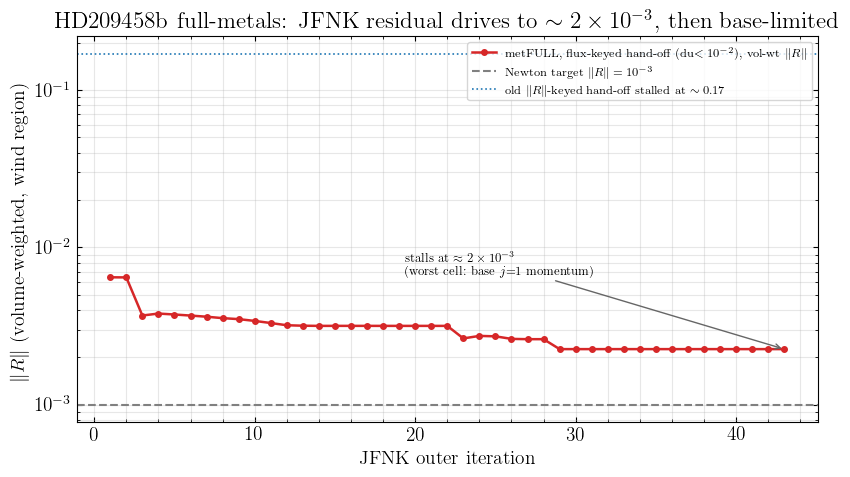

In [7]:
import re

def jfnk_history(folder):
    """Parse '(JFNK) it N ||R||=X' lines from a run's run.log -> (iters, ||R||)."""
    p = os.path.join(folder, 'run.log')
    its, rs = [], []
    if os.path.exists(p):
        for line in open(p):
            m = re.search(r'\(JFNK\) it\s*(\d+)\s*\|\|R\|\|=\s*([0-9.eE+-]+)', line)
            if m:
                its.append(int(m.group(1))); rs.append(float(m.group(2)))
    return its, rs

fig, ax = plt.subplots(figsize=(8.5, 5))
its, rs = jfnk_history('pres1ub_PWN_He1_metFULL_cold_duJFNK')
if its:
    ax.semilogy(its, rs, 'o-', color='C3', lw=1.8, ms=4,
                label=r'metFULL, flux-keyed hand-off (du$<10^{-2}$), vol-wt $\|R\|$')
    ax.annotate(r'stalls at $\approx2\times10^{-3}$' '\n' r'(worst cell: base $j{=}1$ momentum)',
                xy=(its[-1], rs[-1]), xytext=(its[-1]*0.45, rs[-1]*3.0),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='0.4'))
ax.axhline(1e-3, color='0.5', ls='--', label=r'Newton target $\|R\|=10^{-3}$')
ax.axhline(0.17, color='C0', ls=':', lw=1.2,
           label=r'old $\|R\|$-keyed hand-off stalled at $\sim0.17$')
ax.set_xlabel('JFNK outer iteration')
ax.set_ylabel(r'$\|R\|$ (volume-weighted, wind region)')
ax.set_title(r'HD209458b full-metals: JFNK residual drives to $\sim2\times10^{-3}$, then base-limited')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8.5, loc='best')
fig.tight_layout()
plt.show()